# Cascade p-threshold sweep — dataset_3 (ER, avg degree 0.8)

Per-node default cascade (R model). `Ki(p) = (1 - p) * 0.04` shrinks the failure buffer — same idea as
`Equity = (1 - p) * Equity` in Dataset 1/2. Saves one target per `p` to `dataset_3/targets/`
(`target.csv` = p0, then `target_p5..p40.csv`): `bank_id, systemic_risk_label, log_systemic_risk_label`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'requirements.txt').exists())
DATASET_DIR = ROOT / 'src' / 'datasets' / 'dataset_3'
TARGETS_DIR = DATASET_DIR / 'targets'
TARGETS_DIR.mkdir(parents=True, exist_ok=True)

N  = 10000
KI = 0.04
P_LIST = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]

In [2]:
def load_graph():
    e = pd.read_csv(DATASET_DIR / 'edges.csv')
    out = [[] for _ in range(N + 1)]
    for f, t, w in zip(e['from'], e['to'], e['weight']):
        out[f].append((t, w))
    return out

def cascade_size(out, src, ki):
    accum = np.zeros(N + 1); failed = np.zeros(N + 1, bool)
    failed[src] = True; stack = [src]; size = 1
    while stack:
        b = stack.pop()
        for i, w in out[b]:
            if not failed[i]:
                accum[i] += w
                if accum[i] > ki:
                    failed[i] = True; size += 1; stack.append(i)
    return size

## Run the sweep and save a target file per p

In [3]:
out = load_graph()
results = {}
for p in P_LIST:
    ki = (1 - p) * KI
    sizes = np.array([cascade_size(out, v, ki) for v in range(1, N + 1)])
    results[p] = sizes
    fname = 'target.csv' if p == 0 else f'target_p{int(p*100)}.csv'
    pd.DataFrame({'bank_id': np.arange(1, N + 1),
                  'systemic_risk_label': sizes,
                  'log_systemic_risk_label': np.log1p(sizes)}
                 ).to_csv(TARGETS_DIR / fname, index=False)
    print(f'{fname:16s}  Ki={ki:.4f}  mean={sizes.mean():.1f}  max={sizes.max()}')

target.csv        Ki=0.0400  mean=8.2  max=293
target_p5.csv     Ki=0.0380  mean=9.1  max=334
target_p10.csv    Ki=0.0360  mean=9.1  max=334


target_p15.csv    Ki=0.0340  mean=9.1  max=334
target_p20.csv    Ki=0.0320  mean=10.0  max=334
target_p25.csv    Ki=0.0300  mean=10.0  max=334


target_p30.csv    Ki=0.0280  mean=10.0  max=334
target_p35.csv    Ki=0.0260  mean=10.0  max=334
target_p40.csv    Ki=0.0240  mean=10.0  max=334


## Cascade-size distribution per p-threshold

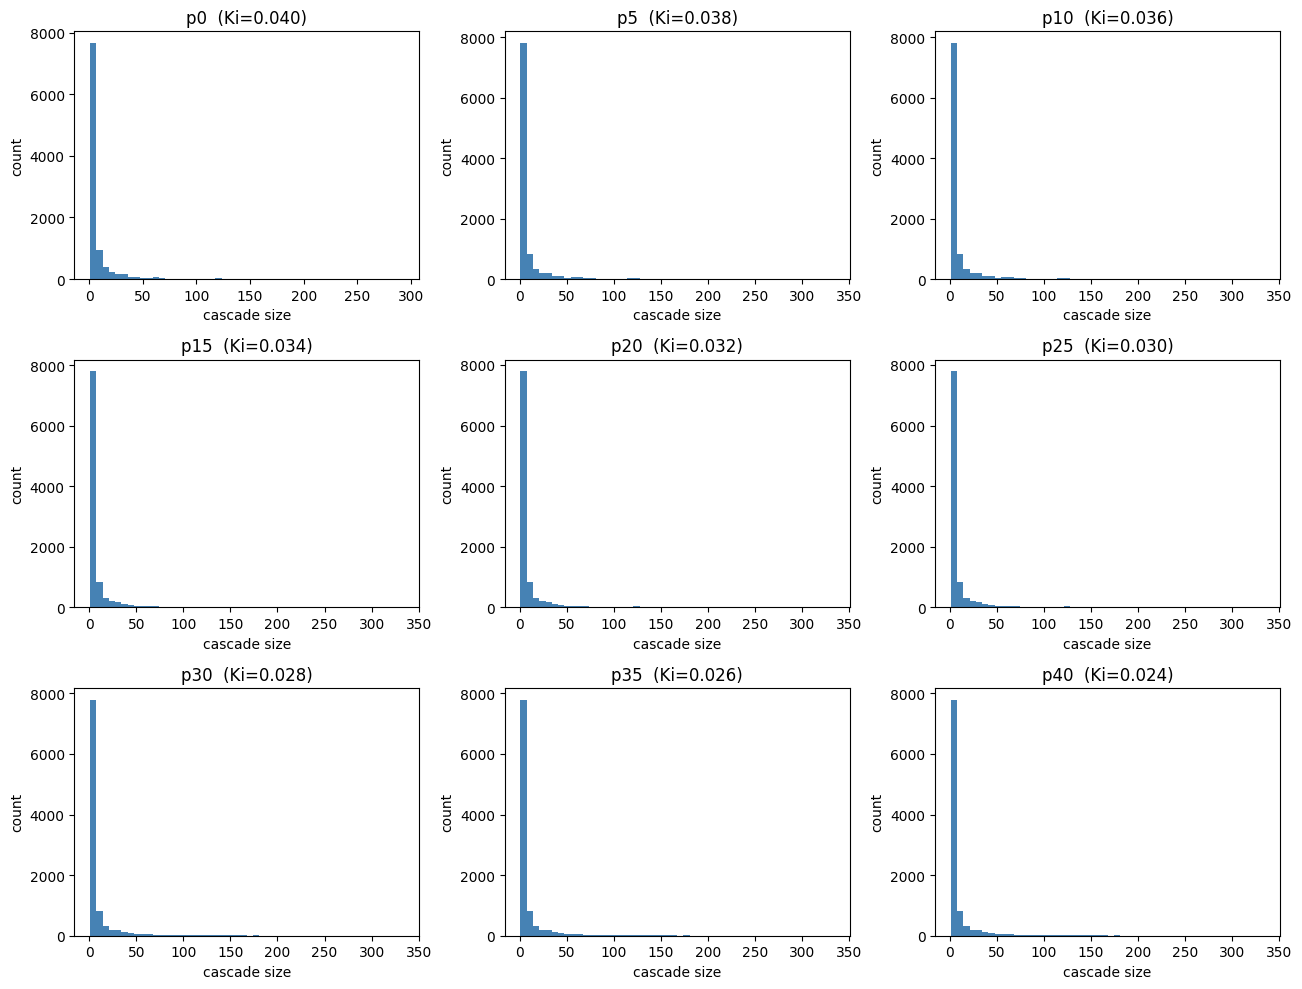

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, p in zip(axes.ravel(), P_LIST):
    ax.hist(results[p], bins=50, color='steelblue')
    ax.set_title(f'p{int(p*100)}  (Ki={(1-p)*KI:.3f})')
    ax.set_xlabel('cascade size'); ax.set_ylabel('count')
fig.tight_layout(); plt.show()